# 0. Data Loading

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../data/test.pickle")



# 1. Library Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
import random
import pickle


# 2. Random Seed Setup

In [3]:
import torch, numpy as np, random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


# 3. Data Preprocessing

C:\Users\anuhe\AppData\Local\Temp\ipykernel_29344\795435323.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_29344\795435323.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access funct

           velocity          mass  deceleration_average
count  4.053000e+03  4.053000e+03          4.053000e+03
mean  -1.039605e-15 -5.049008e-16         -3.155630e-16
std    1.000123e+00  1.000123e+00          1.000123e+00
min   -1.344505e+01 -7.759426e-01         -3.487379e+00
25%   -4.975778e-04 -7.759426e-01         -6.693355e-01
50%   -4.975778e-04 -7.759426e-01          1.530402e-02
75%   -4.975778e-04  1.391196e+00          6.317576e-01
max    2.688413e+00  1.391196e+00          8.531451e+00


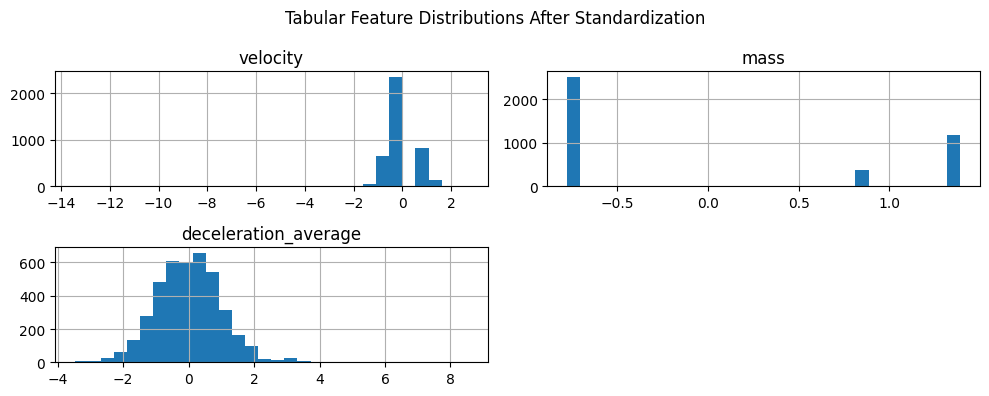

In [ ]:
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt

# def load_pickle(path):
#     with open(path, 'rb') as f:
#         return pickle.load(f)
# # Load and prepare data
# train_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/train.pickle")
# test_data = load_pickle("C:/Study and Work/Sem 6/Neural Networks, Deep Learning and Applications/FSD Project/Original_data/test.pickle")


train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])

X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]

# Separate sensor and tabular data
X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

# Combine tabular data for KNN imputation
X_combined = pd.concat([X_train_tab, X_test_tab], ignore_index=True)

# Perform KNN imputation on the combined tabular data
imputer = KNNImputer(n_neighbors=5)
X_combined_imputed = imputer.fit_transform(X_combined)

# Split back the imputed data into train and test
X_train_tab_imputed = X_combined_imputed[:len(X_train_tab)]
X_test_tab_imputed = X_combined_imputed[len(X_train_tab):]

# Standardize the tabular data
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab_imputed)
X_test_tab_scaled = scaler.transform(X_test_tab_imputed)

# Optionally visualize
tab_df = pd.DataFrame(X_train_tab_scaled, columns=X_train_tab.columns)
print(tab_df.describe())
tab_df.hist(bins=30, figsize=(10, 4))
plt.suptitle("Tabular Feature Distributions After Standardization")
plt.tight_layout()
plt.show()

# Sensor preprocessing
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)

sensor_scaler = RobustScaler()
flat_train_scaled = sensor_scaler.fit_transform(flat_train)
flat_test_scaled = sensor_scaler.transform(flat_test)

X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

X_train_sensor_clipped = np.clip(X_train_sensor_scaled, -5, 5)
X_test_sensor_clipped = np.clip(X_test_sensor_scaled, -5, 5)


# 4.Data Augmentation

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, RobustScaler

# Assume all variables are now defined: X_train_sensor_clipped, X_train_tab_scaled, y_train

# --- Sensor Data Augmentation ---
def augment_sensor_data(X_sensor, y, target_class, n_aug):
    idx = np.where(y == target_class)[0]
    augmented = []
    for _ in range(n_aug):
        sample = X_sensor[np.random.choice(idx)].copy()
        sample += np.random.normal(0, 0.01, sample.shape)
        factor = np.random.uniform(0.9, 1.1, (1, sample.shape[1]))
        sample *= factor
        segs = np.array_split(sample, 4)
        np.random.shuffle(segs)
        sample = np.concatenate(segs, axis=0)
        augmented.append(sample)
    return np.array(augmented), np.full(n_aug, target_class)

# --- Tabular Feature Augmentation ---
def augment_tabular_features(X_tab, y_tab, y_aug, noise_std=0.05):
    X_aug_tab = []
    for label in y_aug:
        class_samples = X_tab[y_tab == label]
        sample = class_samples[np.random.randint(len(class_samples))]
        noise = np.random.normal(0, noise_std, size=sample.shape)
        X_aug_tab.append(sample + noise)
    return np.array(X_aug_tab)

# --- Combined Augmentation ---
def augment_dataset(X_sensor, X_tab, y, target_count=500):
    unique_classes, class_counts = np.unique(y, return_counts=True)
    X_sensor_aug_all = []
    y_aug_all = []

    for cls, count in zip(unique_classes, class_counts):
        n_needed = target_count - count
        if n_needed > 0:
            X_sensor_aug, y_aug = augment_sensor_data(X_sensor, y, cls, n_needed)
            X_sensor_aug_all.append(X_sensor_aug)
            y_aug_all.append(y_aug)

    if not X_sensor_aug_all:
        return X_sensor, X_tab, y  # No augmentation needed

    X_sensor_aug = np.concatenate(X_sensor_aug_all)
    y_aug = np.concatenate(y_aug_all)
    X_tab_aug = augment_tabular_features(X_tab, y, y_aug)

    X_sensor_balanced = np.concatenate([X_sensor, X_sensor_aug])
    X_tab_balanced = np.vstack([X_tab, X_tab_aug])
    y_balanced = np.concatenate([y, y_aug])

    return X_sensor_balanced, X_tab_balanced, y_balanced

# Apply augmentation
X_train_sensor_balanced, X_train_tab_balanced, y_train_balanced = augment_dataset(
    X_sensor=X_train_sensor_clipped,
    X_tab=X_train_tab_scaled,
    y=y_train.values,
    target_count=1200
)

# Check and prepare for training
sensor_shape = X_train_sensor_balanced.shape
tabular_shape = X_train_tab_balanced.shape
label_shape = y_train_balanced.shape

summary_df = pd.DataFrame({
    "Component": ["Sensor Data", "Tabular Features", "Labels"],
    "Shape": [sensor_shape, tabular_shape, label_shape]
})

print("Shapes after augmentation:")
print("Sensor data shape:", X_train_sensor_balanced.shape)
print("Tabular features shape:", X_train_tab_balanced.shape)
print("Labels shape:", y_train_balanced.shape)


Shapes after augmentation:
Sensor data shape: (14998, 128, 6)
Tabular features shape: (14998, 3)
Labels shape: (14998,)


# 5. Model and Training Utilities

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
import random
import pandas as pd

# --- Dataset ---
class SensorDataset(Dataset):
    def __init__(self, sensor_seqs, tabular_feats, labels):
        self.sensor_seqs = torch.tensor(sensor_seqs, dtype=torch.float32)
        self.tabular_feats = torch.tensor(tabular_feats, dtype=torch.float32)
        if isinstance(labels, pd.Series):
            self.labels = torch.tensor(labels.values, dtype=torch.long)
        else:
            self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sensor_seqs[idx], self.tabular_feats[idx], self.labels[idx]

# --- Model ---
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, num_layers=2, tabular_dim=3,
                 tab_hidden_dim=32, output_dim=12, dropout=0.3, bidirectional=True):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )
        lstm_output_dim = hidden_dim * (2 if bidirectional else 1)
        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, tab_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(lstm_output_dim + tab_hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim)
        )

    def forward(self, x_seq, x_tab):
        lstm_out, _ = self.lstm(x_seq)
        lstm_last = lstm_out[:, -1, :]
        tab_out = self.tabular_net(x_tab)
        combined = torch.cat((lstm_last, tab_out), dim=1)
        return self.classifier(combined)

# --- Training ---
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_seq, x_tab, y in dataloader:
        x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x_seq, x_tab)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_f1(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return f1_score(all_labels, all_preds, average='weighted')

# --- Hyperparameter Search ---
param_space = {
    'hidden_dim': [32, 64, 128],
    'num_layers': [1, 2],
    'bidirectional': [True, False],
    'dropout': [0.1, 0.3, 0.5],
    'tab_hidden_dim': [16, 32, 64],
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'batch_size': [32, 64, 128]
}

def sample_hyperparams(param_space):
    return {k: random.choice(v) for k, v in param_space.items()}

def run_random_search_cv(sensor_data, tab_data, labels, num_trials=10, num_epochs=10, device='cuda'):
    best_f1 = -1
    best_params = None
    best_model_state = None

    for trial in range(num_trials):
        print(f"\nTrial {trial+1}/{num_trials}")
        params = sample_hyperparams(param_space)
        print("Params:", params)

        all_f1_scores = []
        for split in range(10):
            X_tr, X_val, T_tr, T_val, y_tr, y_val = train_test_split(
                sensor_data, tab_data, labels,
                test_size=0.2, stratify=labels, random_state=split + trial * 100
            )

            train_ds = SensorDataset(X_tr, T_tr, y_tr)
            val_ds = SensorDataset(X_val, T_val, y_val)

            train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
            val_loader = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)

            model = LSTMClassifier(
                input_dim=sensor_data.shape[2],
                hidden_dim=params['hidden_dim'],
                num_layers=params['num_layers'],
                tabular_dim=tab_data.shape[1],
                tab_hidden_dim=params['tab_hidden_dim'],
                output_dim=len(np.unique(labels)),
                dropout=params['dropout'],
                bidirectional=params['bidirectional']
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])
            criterion = nn.CrossEntropyLoss()

            for epoch in range(num_epochs):
                train_one_epoch(model, train_loader, optimizer, criterion, device)

            f1 = evaluate_f1(model, val_loader, device)
            all_f1_scores.append(f1)

        avg_f1 = np.mean(all_f1_scores)
        print(f"Average F1 score: {avg_f1:.4f}")

        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_params = params
            best_model_state = model.state_dict()
            torch.save(best_model_state, "AUG_LSTM_1_BEST_MODEL.pth")

    print("\nBest Hyperparameters Found:")
    print(best_params)
    print(f"Best Average F1: {best_f1:.4f}")
    return best_params, best_f1, best_model_state


# 6.Data distribution after Augmentation

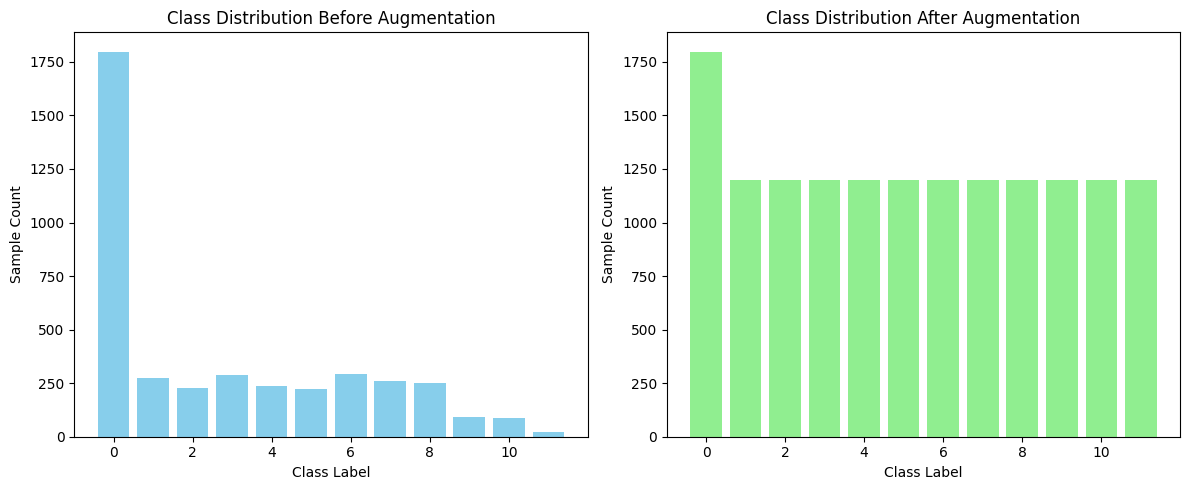

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Plot histogram before augmentation
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts, color='skyblue')
plt.title("Class Distribution Before Augmentation")
plt.xlabel("Class Label")
plt.ylabel("Sample Count")

# Plot histogram after augmentation
plt.subplot(1, 2, 2)
unique_aug, counts_aug = np.unique(y_train_balanced, return_counts=True)
plt.bar(unique_aug, counts_aug, color='lightgreen')
plt.title("Class Distribution After Augmentation")
plt.xlabel("Class Label")
plt.ylabel("Sample Count")

plt.tight_layout()
plt.show()


# 7. Model and Training

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

best_params, best_f1, best_model_state = run_random_search_cv(
    sensor_data=X_train_sensor_balanced,
    tab_data=X_train_tab_balanced,
    labels=y_train_balanced,
    num_trials=10,  # or fewer for quick testing
    num_epochs=30,
    device=device
)



Trial 1/10
Params: {'hidden_dim': 32, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.5, 'tab_hidden_dim': 32, 'learning_rate': 0.0001, 'batch_size': 32}
Average F1 score: 0.8707

Trial 2/10
Params: {'hidden_dim': 32, 'num_layers': 1, 'bidirectional': True, 'dropout': 0.5, 'tab_hidden_dim': 64, 'learning_rate': 0.0001, 'batch_size': 128}
Average F1 score: 0.7630

Trial 3/10
Params: {'hidden_dim': 32, 'num_layers': 2, 'bidirectional': True, 'dropout': 0.3, 'tab_hidden_dim': 64, 'learning_rate': 0.0005, 'batch_size': 32}
Average F1 score: 0.9917

Trial 4/10
Params: {'hidden_dim': 32, 'num_layers': 2, 'bidirectional': False, 'dropout': 0.3, 'tab_hidden_dim': 16, 'learning_rate': 0.0001, 'batch_size': 64}
Average F1 score: 0.8269

Trial 5/10
Params: {'hidden_dim': 32, 'num_layers': 1, 'bidirectional': False, 'dropout': 0.1, 'tab_hidden_dim': 32, 'learning_rate': 0.0005, 'batch_size': 128}
Average F1 score: 0.9416

Trial 6/10
Params: {'hidden_dim': 64, 'num_layers': 1, 'bidirectional'

# 8. Best Model Loading

In [7]:

best_params = {
    'hidden_dim': 128,
    'num_layers': 2,
    'bidirectional': False,
    'dropout': 0.5,
    'tab_hidden_dim': 16,
    'learning_rate': 0.001,
    'batch_size': 32
}
device = 'cuda' if torch.cuda.is_available() else 'cpu'

best_model = LSTMClassifier(
    input_dim=X_train_sensor_balanced.shape[2],
    hidden_dim=best_params['hidden_dim'],
    num_layers=best_params['num_layers'],
    tabular_dim=X_train_tab_balanced.shape[1],
    tab_hidden_dim=best_params['tab_hidden_dim'],
    output_dim=len(np.unique(y_train_balanced)),
    dropout=best_params['dropout'],
    bidirectional=best_params['bidirectional']
).to(device)

best_model.load_state_dict(torch.load("AUG_LSTM_1_BEST_MODEL.pth"))
best_model.eval()


LSTMClassifier(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.5)
  (tabular_net): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=144, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True)
  )
)

# 9. Test Loader preparation

In [8]:
test_dataset = SensorDataset(X_test_sensor_clipped, X_test_tab_scaled, y_test)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)


# 10. Test Evaluation

In [9]:
from sklearn.metrics import accuracy_score

def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab, y = x_seq.to(device), x_tab.to(device), y.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    acc = accuracy_score(all_labels, all_preds)
    return f1, acc

test_f1, test_acc = evaluate_model(best_model, test_loader, device)

print(f"\n Test F1 Score: {test_f1:.4f}")
print(f" Test Accuracy: {test_acc:.4f}")



 Test F1 Score: 0.4755
 Test Accuracy: 0.3766


# 11. Confusion Matrix

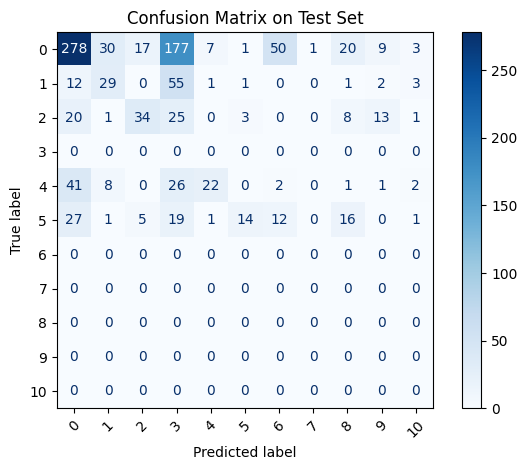

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Run model and collect predictions/labels
def get_preds_and_labels(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab = x_seq.to(device), x_tab.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    return all_preds, all_labels

preds, labels = get_preds_and_labels(best_model, test_loader, device)

# Compute and display confusion matrix
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.show()


# 12. Confusion Matrix Normalized

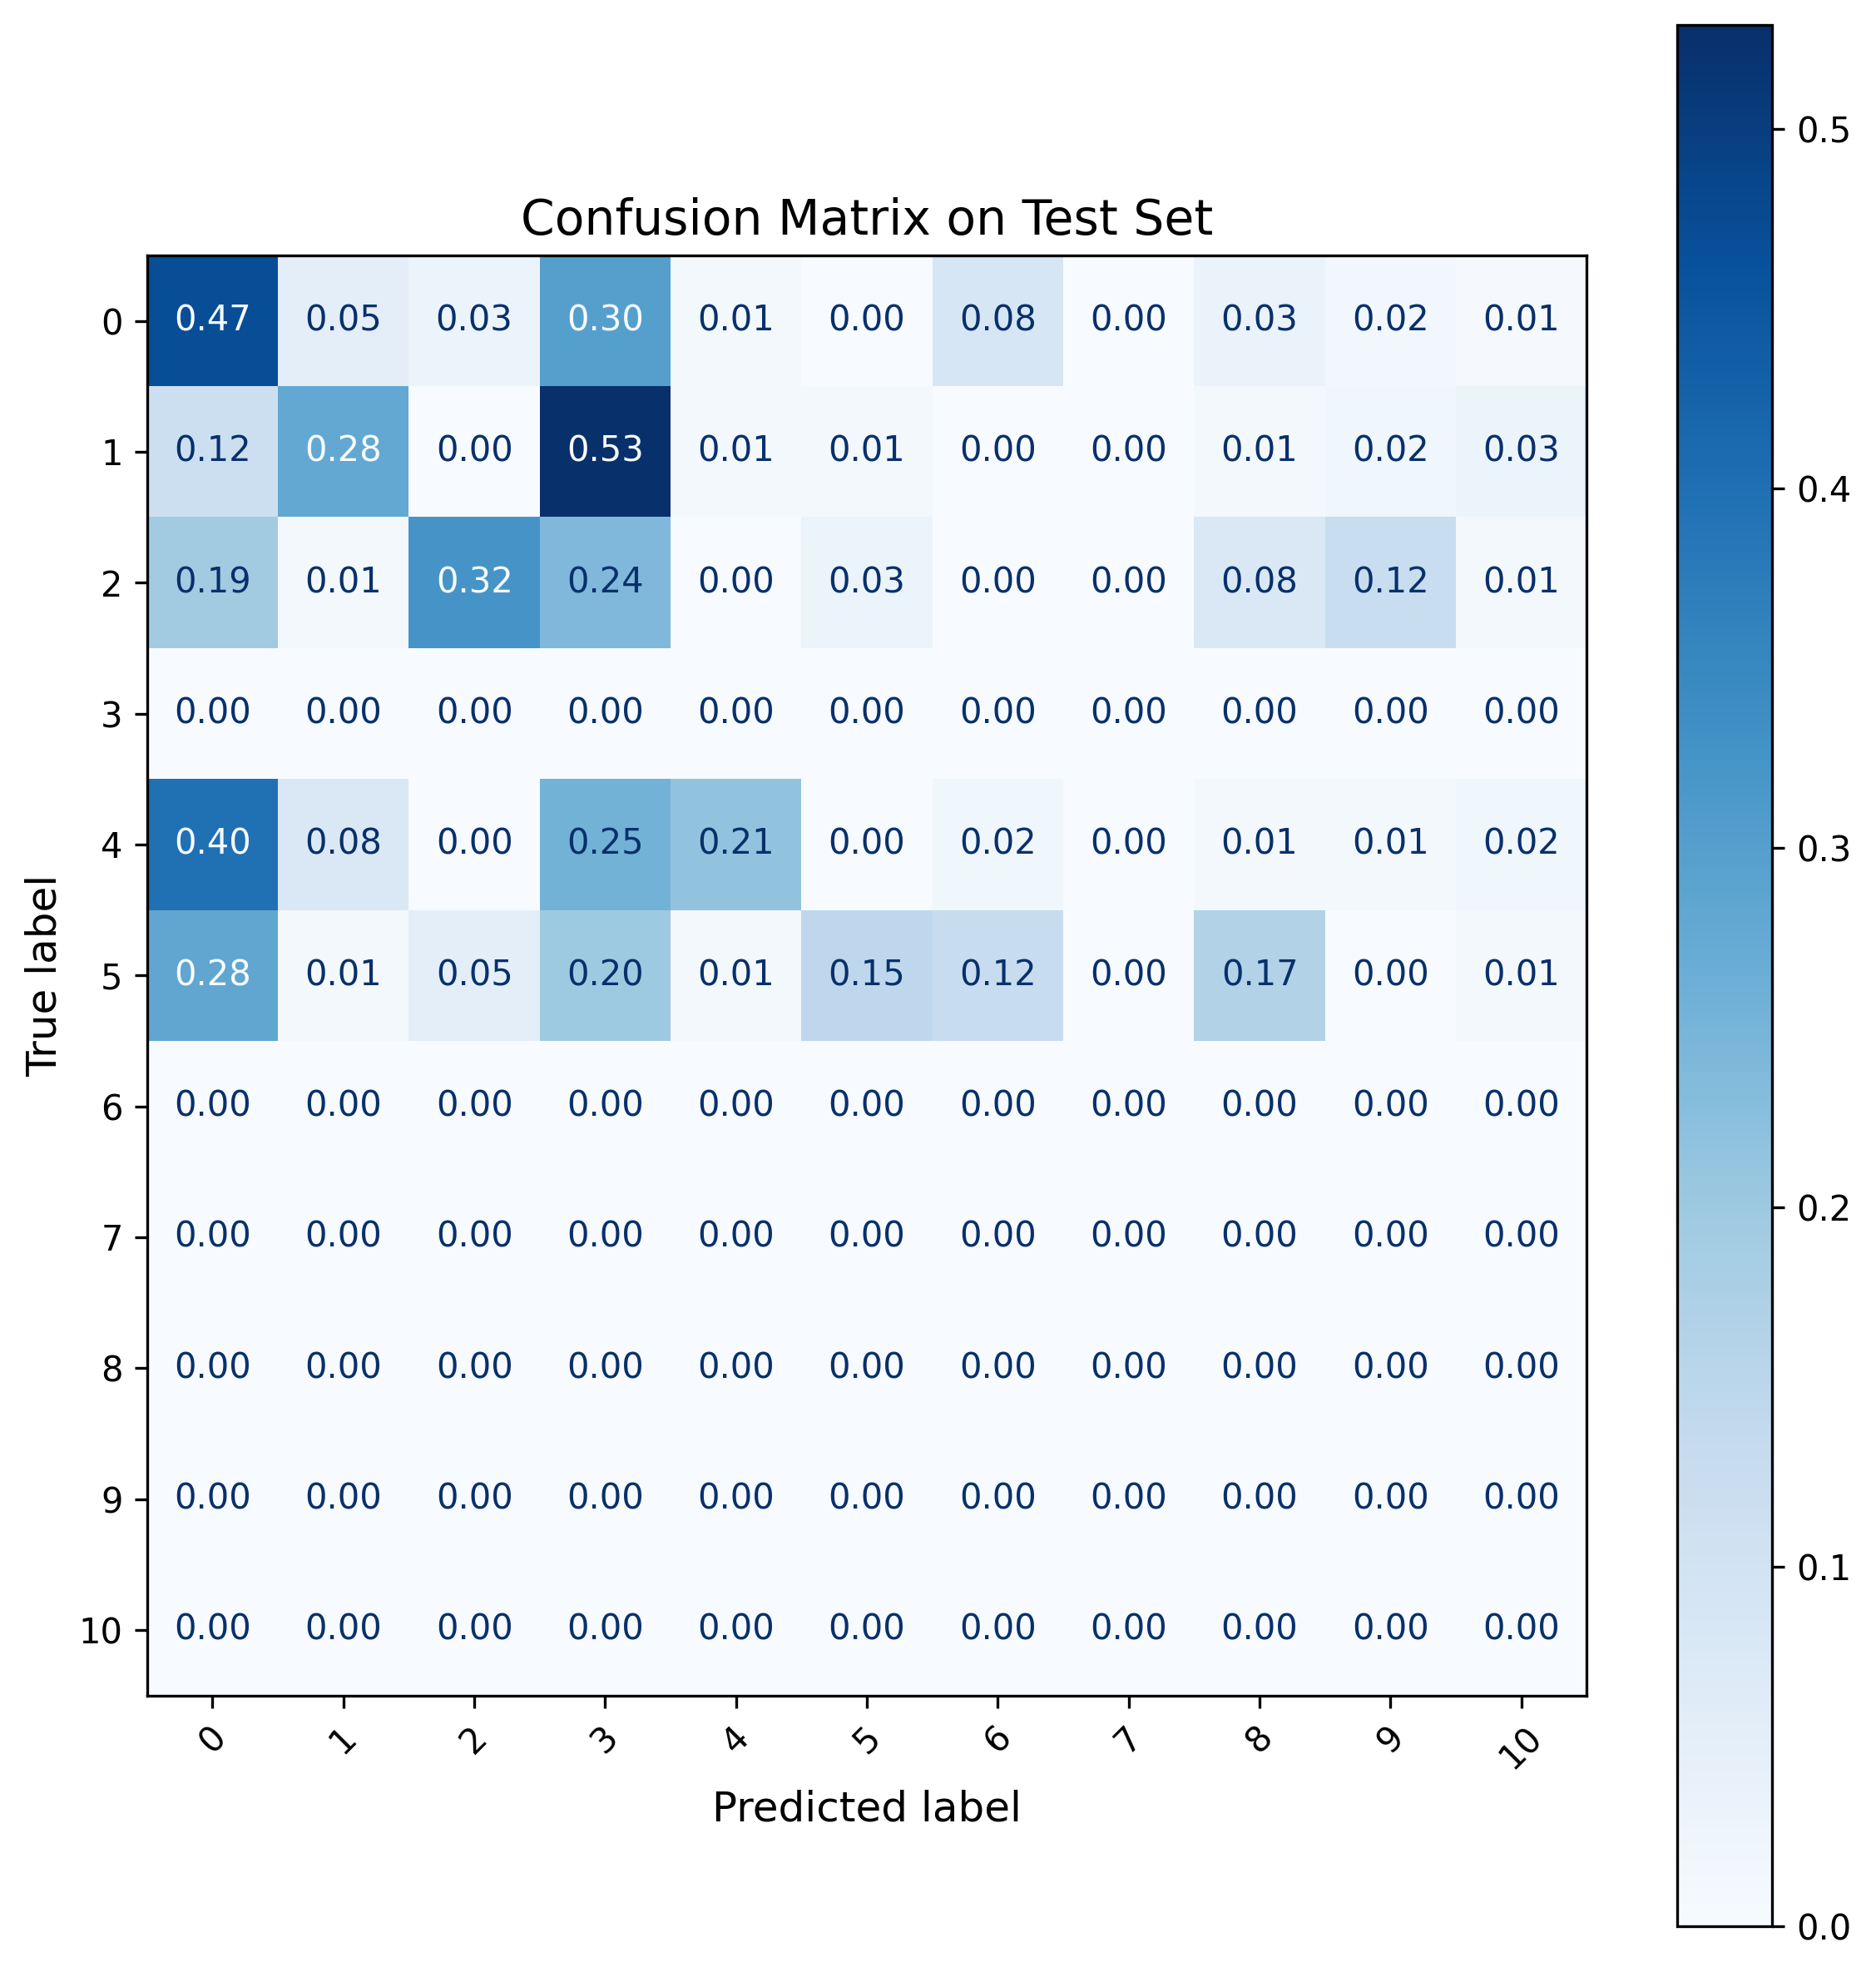

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Run model and collect predictions/labels
def get_preds_and_labels(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_tab, y in dataloader:
            x_seq, x_tab = x_seq.to(device), x_tab.to(device)
            outputs = model(x_seq, x_tab)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())
    return all_preds, all_labels

preds, labels = get_preds_and_labels(best_model, test_loader, device)

# Compute confusion matrix
cm = confusion_matrix(labels, preds, normalize="true")

# Create better plot
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(
    cmap='Blues',
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
    colorbar=True
)

# Improve visuals
ax.set_title("Confusion Matrix on Test Set", fontsize=14)
ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()

# Save the figure
#fig.savefig("C:/Study and work/Sem 6/Neural Networks, Deep Learning and Applications/Report/case_4_result.jpg", dpi=300)
plt.show()
